<a href="https://colab.research.google.com/github/ryan-merser/ST554-BigData/blob/main/HW8/ST554_HW8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ST554 Analysis of Big Data Homework 7

Ryan Mersereau

In this notebook, we will get some practice fitting MLR and logistic regression models using the wine dataset found from the UCI machine learning repository  [ here.](https://archive.ics.uci.edu/dataset/186/wine+quality)

The data description describes the following variables:
1. - fixed acidity
2. - volatile acidity
3. - citric acid
4. - residual sugar
5. - chlorides
6. - free sulfur dioxide
7. - total sulfur dioxide
8. - density
9. - pH
10. - sulphates
11. - alcohol
12. - quality (score between 0 and 10)

In this notebook we'll be using alcohol as our target variable for multiple linear regression, and for fitting logistic regression type models we’ll use the type of wine as the response variable.

## Reading in and combining data

We'll start by uploading each dataset via a local path, and then combining them and create a new variable that represents the type of wine (red or white).

In [1]:
import pandas as pd
import numpy as np
red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')

In [2]:
red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [35]:
white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white


In [36]:
white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
 12  type                  4898 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 497.6+ KB


In [3]:
# Add type variable
red['type'] = 'red'
white['type'] = 'white'

# Combine
total_wine = pd.concat([red, white], ignore_index= True)

In [4]:
total_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## Split data

Now, lets split up the data set into a training and test set. For this, I want you to use stratified sampling to
make sure that you have a similar proportion of white and red wines in the training and test sets. This
can be done with the `train_test_split()` function.

We also need to encode our categorical variable for type of wine as a binary variable (0 or 1) to avoid issues.

In [5]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn import preprocessing

In [6]:
# Encode type as binary, red is 0, white is 1
enc = preprocessing.OrdinalEncoder()
total_wine[['type']] = enc.fit_transform(total_wine[['type']])
print(enc.categories_)

[array(['red', 'white'], dtype=object)]


In [7]:
X = total_wine.drop(columns=['alcohol'])
y = total_wine['alcohol']

# Create test/train split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # Typically want an 80/20 split, train on 80%, test on 20%
    random_state = 7,
    stratify = X['type']
)


In [8]:
# Ensure stratification worked
print("Full dataset:")
print(X['type'].value_counts(normalize=True).round(3))

print("\nTraining set:")
print(X_train['type'].value_counts(normalize=True).round(3))

print("\nTest set:")
print(X_test['type'].value_counts(normalize=True).round(3))

Full dataset:
type
1.0    0.754
0.0    0.246
Name: proportion, dtype: float64

Training set:
type
1.0    0.754
0.0    0.246
Name: proportion, dtype: float64

Test set:
type
1.0    0.754
0.0    0.246
Name: proportion, dtype: float64


We have about 75% white and 25% red wines in the full, training, and test dataset.

### Standardize Predictors

Before we start training, let's standardize our predictor values to have mean 0 and sd 1

In [9]:
means = X_train.apply(np.mean, axis = 0)
stds = X_train.apply(np.std, axis = 0)
means.head()

,0
fixed acidity,7.223167
volatile acidity,0.339449
citric acid,0.318451
residual sugar,5.430633
chlorides,0.055925


In [10]:
# Standardize X_train using its own means and stds
X_train = (X_train - means) / stds

# Standardize X_test using X_train's means and stds
X_test = (X_test - means) / stds

In [11]:
X_train.apply(np.mean, axis = 0)
X_train.apply(np.std, axis = 0)

,0
fixed acidity,1.0
volatile acidity,1.0
citric acid,1.0
residual sugar,1.0
chlorides,1.0
free sulfur dioxide,1.0
total sulfur dioxide,1.0
density,1.0
pH,1.0
sulphates,1.0


## I. Model Training to predict `alcohol`

### Multiple Linear Regression (MLR) Models

We will now fit four different multiple linear regression models.
* At least one should include interaction terms
* At least one should include some polynomial terms
* Use CV to select your best MLR model

In [12]:
from sklearn.preprocessing import PolynomialFeatures

# Model 1: Basic MLR with all features
cv_mlr1 = cross_validate(
    LinearRegression(),
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error")

# Model 2: MLR with interaction terms, contains all interactions
X_train_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False).fit_transform(X_train)
cv_mlr2 = cross_validate(
    LinearRegression(),
    X_train_interact,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error")

# Model 3: MLR with polynomial terms, contains all interactions + polynomial terms
X_train_poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False).fit_transform(X_train)
cv_mlr3 = cross_validate(
    LinearRegression(),
    X_train_poly,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error")

# Model 4: MLR with subset of features + manual interaction and polynomial terms
X_train_custom = X_train[["residual sugar", "density", "type"]].copy()
X_train_custom["sugar_x_type"] = X_train["residual sugar"] * X_train["type"]
X_train_custom["density_sq"] = X_train["density"] ** 2
cv_mlr4 = cross_validate(
    LinearRegression(),
    X_train_custom,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error")

In [37]:
# Compare RMSE across all four models
print(np.sqrt(-np.mean(cv_mlr1['test_score'])),
      np.sqrt(-np.mean(cv_mlr2['test_score'])),
      np.sqrt(-np.mean(cv_mlr3['test_score'])),
      np.sqrt(-np.mean(cv_mlr4['test_score'])))

0.5202704161000903 0.44346990720605944 0.4498168369060473 0.7564442059431449


From this output, our second model with interaction terms appears to be the best MLR model, having the lowest Root mean squared error.

In [38]:
mlr_best = LinearRegression().fit(X_train_interact, y_train)
print(mlr_best.intercept_)
print(np.array(list(zip(X_train.columns, mlr_best.coef_))))

10.342414045805445
[['fixed acidity' '0.6728307232998706']
 ['volatile acidity' '0.09448792937169068']
 ['citric acid' '0.0726211612170754']
 ['residual sugar' '1.1384644220769264']
 ['chlorides' '-0.009436266348793021']
 ['free sulfur dioxide' '-0.07740237955735757']
 ['total sulfur dioxide' '0.06205711267245362']
 ['density' '-2.0465117229471277']
 ['pH' '0.42522716948572814']
 ['sulphates' '0.15183575115244896']
 ['quality' '0.056698286690855415']
 ['type' '-0.5269500022796357']]


This output shows the intercept and Beta values associated with estimated coefficients of our best MLR model.

### LASSO model

Next, we'll create a Lasso model using LassoCV.

This is a Least absolute shrinkage and selection operator (LASSO) that adds a penalty to the model for having large coefficients, regularizing and selecting features.

We'll choose six of the predictors (chosen arbitrarily) for our model and use Cross validation to select the tuning parameter.

In [39]:
# Predictor selection
features = ["fixed acidity", "volatile acidity", "residual sugar", "density", "type", "pH"]

X_train_lasso = X_train[features]
X_test_lasso = X_test[features]

lasso_mod = LassoCV(
    alphas = np.logspace(-4, 1, 100), # Tests 100 alpha values between 0.0001 and 10
    cv = 5,
    random_state = 7
)
lasso_mod.fit(X_train_lasso, y_train)

LassoCV(alphas=array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6.42807312e-04, 7.22080902e-04, 8.11130831e-04, 9.11162756e-04,
       1.02353102e-03, 1.14975700e-0...
       6.89261210e-01, 7.74263683e-01, 8.69749003e-01, 9.77009957e-01,
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01]),
        cv=5, random_state=7)

In [40]:
# Best alpha
print(lasso_mod.alpha_)

# Intercept
print(lasso_mod.intercept_)

# Coefficients
print(np.array(list(zip(X_train_lasso.columns, lasso_mod.coef_))))

0.0006428073117284319
10.491021743313523
[['fixed acidity' '0.7653770048755917']
 ['volatile acidity' '0.05788450878891965']
 ['residual sugar' '1.1072941746157823']
 ['density' '-2.02314384117133']
 ['type' '-0.5747068517424108']
 ['pH' '0.44821896604727596']]


This output gives us the best alpha parameter, and the intercept and coefficients of our LASSO model.

In [41]:
# CV RMSE at best alpha
cv_lasso_rmse = np.sqrt(np.min(np.mean(lasso_mod.mse_path_, axis=1)))
cv_lasso_rmse

np.float64(0.5482423088455753)

### Ridge Regression Model

Now, let's build a model using ridge regression. This is similar to LASSO, but
penalizes squared values of coefficients instead of absolute values

In [42]:
from sklearn.linear_model import Ridge, RidgeCV

# Predictor selection - Here we'll choose slightly different predictors than with LASSO
features = ["fixed acidity", "volatile acidity", "residual sugar", "density", "type", "pH"]

X_train_ridge = X_train[features]
X_test_ridge = X_test[features]

ridge_mod = RidgeCV(
    alphas=np.logspace(-4, 1, 100),  # range of alphas to try
    cv=5
)

ridge_mod.fit(X_train_ridge, y_train)

RidgeCV(alphas=array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6.42807312e-04, 7.22080902e-04, 8.11130831e-04, 9.11162756e-04,
       1.02353102e-03, 1.14975700e-0...
       6.89261210e-01, 7.74263683e-01, 8.69749003e-01, 9.77009957e-01,
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01]),
        cv=5)

In [43]:
# Best alpha (tuning parameter)
print(ridge_mod.alpha_)

# Intercept
print(ridge_mod.intercept_)

# Coefficients
# Coefficients
print(np.array(list(zip(X_train_ridge.columns, ridge_mod.coef_))))

2.477076355991709
10.491021743313523
[['fixed acidity' '0.766189723615325']
 ['volatile acidity' '0.05860855809656256']
 ['residual sugar' '1.1081535226787143']
 ['density' '-2.0238045967070137']
 ['type' '-0.5745205620702706']
 ['pH' '0.4489513744737726']]


Again, this output gives us the best alpha tuning parameter, and the intercept and coefficients of the ridge regression model.

### Elastic Net

Finally, we'll create a model using the ElasticNet method. This is a blend of LASSO and ridge regression, and has an additional tuning parameter: L1 ratio that controls the mix of the two.

In [44]:
from sklearn.linear_model import ElasticNet, ElasticNetCV

# Predictor selection
features = ["fixed acidity", "volatile acidity", "residual sugar", "density", "type", "pH"]

X_train_enet = X_train[features]
X_test_enet = X_test[features]

#ElasticNetCV

regr = ElasticNetCV(
    alphas=np.logspace(-4, 1, 100),   # range of alphas to try
    l1_ratio=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1],  # range of l1_ratios to try
    cv=5,
    random_state=7
)
regr.fit(X_train_enet, y_train)


ElasticNetCV(alphas=array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6.42807312e-04, 7.22080902e-04, 8.11130831e-04, 9.11162756e-04,
       1.02353102e-03, 1.149757...
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01]),
             cv=5, l1_ratio=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1],
             random_state=7)

In [45]:
# Best alpha
print(regr.alpha_)

# Best l1 ratio
print(regr.l1_ratio_)

0.0008111308307896872
0.1


In [46]:
# Re-fit on full training data with best tuning parameters
en = ElasticNet(alpha = regr.alpha_, l1_ratio = regr.l1_ratio_)
en.fit(X_train_enet, y_train)
print(np.array(list(zip(X_train_enet.columns, en.coef_))))

[['fixed acidity' '0.7637617779298622']
 ['volatile acidity' '0.0584795331137841']
 ['residual sugar' '1.1035560626770735']
 ['density' '-2.018672464182166']
 ['type' '-0.572401053330177']
 ['pH' '0.44760077528898684']]


## Testing

• Now, using our four selected models, let's compare their performance on the test set. We will do so using RMSE (root mean squared error) and MAE (mean absolute error) as the model metrics.

In [47]:
# Four best models
X_test_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False).fit_transform(X_test)
X_test_sub = X_test[["fixed acidity", "volatile acidity", "residual sugar", "density", "type", "pH"]]

# Generate predictions from each model
mlr_pred = mlr_best.predict(X_test_interact)
lasso_pred = lasso_mod.predict(X_test_sub)
ridge_pred = ridge_mod.predict(X_test_sub)
enet_pred  = en.predict(X_test_sub)

models = {
    "MLR (Interactions)": mlr_pred,
    "LASSO": lasso_pred,
    "Ridge": ridge_pred,
    "Elastic Net": enet_pred
}

# Compare RMSE and MAE for all models
print(f"{'Model':<19} {'RMSE':>10} {'MAE':>7}")
print("-" * 47)
for name, preds in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    print(f"{name:<25} {rmse:>8.7f} {mae:>8.7f}")

Model                     RMSE     MAE
-----------------------------------------------
MLR (Interactions)        0.4073226 0.3120145
LASSO                     0.4787821 0.3629611
Ridge                     0.4788063 0.3629887
Elastic Net               0.4790397 0.3632837


MLR appears to have to lowest RMSE and MAE, but has many more predictors compared to the other two. If this were an actual experiment, we may prefer LASSO as it could be much more cost effect effective compared to MLR. LASSO, Ridge regression, and elastic net all performed similarly well as the models were trained with the same six parameters, with LASSO slightly edging out the other two methods.

## II. Classification using wine `type` as response

Now, we'll switch gears and do some logistic regression. We will try and predict `type` of wine (red or white) using all the other variables as predictors. This will be a similar process as before; splitting the data, comparing several models, and evaluating them against the test data.

In [13]:
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

# New x and y for predicting type
X_class = total_wine.drop(columns=['type'])
y_class = total_wine['type']

# Train/test split
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class,
    test_size=0.2,
    random_state=7,
    stratify=y_class
)

# Standardize
means_class = X_train_class.mean(axis=0)
stds_class = X_train_class.std(axis=0)

X_train_class = (X_train_class - means_class) / stds_class
X_test_class = (X_test_class - means_class) / stds_class

### Multiple predictors Model Fitting

In [29]:
# Model fitting

# Model 1: Basic logistic regression (all features)
log_mod1 = LogisticRegressionCV(
    Cs=250,   # Cs is inverse of alpha
    cv=5,
    solver = "newton-cholesky", # Using newton-cholesky solver to find Beta hats
    scoring='neg_log_loss',
    random_state=7,
    max_iter=1000
)
log_mod1.fit(X_train_class, y_train_class)



LogisticRegressionCV(Cs=250, cv=5, max_iter=1000, random_state=7,
                     scoring='neg_log_loss', solver='newton-cholesky')

In [30]:
# Model 2: Logistic regression with interaction terms
X_train_class_interact = PolynomialFeatures(degree=2, interaction_only=True,
                                           include_bias=False).fit_transform(X_train_class)
log_mod2 = LogisticRegressionCV(
    Cs=250,
    cv=5,
    solver = "newton-cholesky",
    scoring='neg_log_loss',
    random_state=7,
    max_iter=1000
)
log_mod2.fit(X_train_class_interact, y_train_class)

LogisticRegressionCV(Cs=250, cv=5, max_iter=1000, random_state=7,
                     scoring='neg_log_loss', solver='newton-cholesky')

In [48]:
# Model 3: Logistic regression with subset of features
features_class = ["volatile acidity", "residual sugar", "total sulfur dioxide",
                "density", "sulphates", "quality"]
X_train_class_sub = X_train_class[features_class]
log_mod3 = LogisticRegressionCV(
    Cs=250,
    cv=5,
    solver = "newton-cholesky",
    scoring='neg_log_loss',
    random_state=7,
    max_iter=1000
)
log_mod3.fit(X_train_class_sub, y_train_class)



LogisticRegressionCV(Cs=250, cv=5, max_iter=1000, random_state=7,
                     scoring='neg_log_loss', solver='newton-cholesky')

In [49]:
# Model 4: Logistic regression with polynomial terms
X_train_clf_poly = X_train_class.copy()
for col in X_train_class.columns:
    X_train_clf_poly[f"{col}_sq"] = X_train_class[col] ** 2
log_mod4 = LogisticRegressionCV(
    Cs=250,
    cv=5,
    solver = "newton-cholesky",
    scoring='neg_log_loss',
    random_state=7,
    max_iter=1000
)
log_mod4.fit(X_train_clf_poly, y_train_class)

LogisticRegressionCV(Cs=250, cv=5, max_iter=1000, random_state=7,
                     scoring='neg_log_loss', solver='newton-cholesky')

Now, we'll compare CV log-loss across models during training


In [50]:
models_clf = {
    "Logistic Basic":        log_mod1,
    "Logistic Interactions": log_mod2,
    "Logistic Subset":       log_mod3,
    "Logistic Polynomial":   log_mod4
}

print("CV Log-Loss:")
for name, mod in models_clf.items():
    # scores_ shape is (n_Cs, n_folds) — take best mean across Cs
    best_score = np.min(np.mean(mod.scores_[1.0], axis=0))
    print(f"  {name}: {-best_score:.4f}")

CV Log-Loss:
  Logistic Basic: 0.4284
  Logistic Interactions: 0.3363
  Logistic Subset: 0.4674
  Logistic Polynomial: 0.3773


#### Multiple predictors evaluation

In [51]:
# Prepare test sets for each model
X_test_class_interact = PolynomialFeatures(degree=2, interaction_only=True,
                                          include_bias=False).fit_transform(X_test_class)
X_test_class_sub  = X_test_class[features_class]
X_test_class_poly = X_test_class.copy()
for col in X_test_class.columns:
    X_test_class_poly[f"{col}_sq"] = X_test_class[col] ** 2

# Generate predictions
test_sets = {
    "Logistic Basic":        (log_mod1, X_test_class),
    "Logistic Interactions": (log_mod2, X_test_class_interact),
    "Logistic Subset":       (log_mod3, X_test_class_sub),
    "Logistic Polynomial":   (log_mod4, X_test_class_poly)
}

print(f"{'Model':<25} {'Log-Loss':>10} {'Accuracy':>10}")
print("-" * 47)
for name, (mod, X_test_i) in test_sets.items():
    preds_prob  = mod.predict_proba(X_test_i)
    preds_class = mod.predict(X_test_i)
    ll  = log_loss(y_test_class, preds_prob)
    acc = accuracy_score(y_test_class, preds_class)
    print(f"{name:<25} {ll:>10.4f} {acc:>10.4f}")

Model                       Log-Loss   Accuracy
-----------------------------------------------
Logistic Basic                0.0274     0.9938
Logistic Interactions         0.0181     0.9946
Logistic Subset               0.0323     0.9900
Logistic Polynomial           0.0226     0.9954


The second logistic regression model, with only interaction terms appears to do the best in terms of minimizing log-loss, and maximizing accuracy. With a log-loss of 0.018, and accuracy of 99.46%, very high! A naive model should have an accuracy of about 75% (because that is how many white wines are in the data if it predicts white every time).

The third model with only a subset of predictors does the worst in terms of log-loss, but this may be because the other models have much more predictors, and are not penalized, so this could be an area of improvement.

### L1 (LASSO) Logistic model

In [31]:
# L1 penalty — like LASSO, can shrink coefficients to exactly zero (feature selection)
log_lasso = LogisticRegressionCV(
    Cs=250,
    cv=5,
    penalty='l1',
    solver='saga',        # saga or liblinear required for L1
    scoring='neg_log_loss',
    random_state=7,
    max_iter=1000
)
log_lasso.fit(X_train_class[["fixed acidity", "volatile acidity", "residual sugar", "density", "alcohol", "pH"]], y_train_class)

LogisticRegressionCV(Cs=250, cv=5, max_iter=1000, penalty='l1', random_state=7,
                     scoring='neg_log_loss', solver='saga')

### L2 (Ridge) Logistic model

In [32]:
# L2 penalty (default) — like Ridge, shrinks coefficients but keeps all terms
log_ridge = LogisticRegressionCV(
    Cs=250,
    cv=5,
    penalty='l2',         # this is the default
    solver='saga',
    scoring='neg_log_loss',
    random_state=7,
    max_iter=1000
)
log_ridge.fit(X_train_class[["fixed acidity", "volatile acidity", "residual sugar", "density", "alcohol", "pH"]], y_train_class)

LogisticRegressionCV(Cs=250, cv=5, max_iter=1000, random_state=7,
                     scoring='neg_log_loss', solver='saga')

### Elastic Net Logistic model

In [33]:
# Elastic Net — mix of L1 and L2, requires l1_ratios
log_elastic = LogisticRegressionCV(
    Cs=250,
    cv=5,
    penalty='elasticnet',
    solver='saga',        # saga required for elasticnet
    l1_ratios=[0.1, 0.5, 0.9],
    scoring='neg_log_loss',
    random_state=7,
    max_iter=1000
)
log_elastic.fit(X_train_class[["fixed acidity", "volatile acidity", "residual sugar", "density", "alcohol", "pH"]], y_train_class)

LogisticRegressionCV(Cs=250, cv=5, l1_ratios=[0.1, 0.5, 0.9], max_iter=1000,
                     penalty='elasticnet', random_state=7,
                     scoring='neg_log_loss', solver='saga')

### Testing all Logistic models

In [52]:
# Prepare test sets matching exactly what each model was trained on
X_test_interact = PolynomialFeatures(degree=2, interaction_only=True,
                                      include_bias=False).fit_transform(X_test_class)
X_test_csub = X_test_class[["fixed acidity", "volatile acidity", "residual sugar", "density", "alcohol", "pH"]]

# Map models to their corresponding test sets
test_sets = {
    "Logistic Interactions": (log_mod2,    X_test_interact),
    "Logistic LASSO":        (log_lasso,   X_test_csub),
    "Logistic Ridge":        (log_ridge,   X_test_csub),
    "Logistic Elastic Net":  (log_elastic, X_test_csub)
}

# Compare log-loss and accuracy
print(f"{'Model':<25} {'Log-Loss':>10} {'Accuracy':>10}")
print("-" * 47)
for name, (mod, X_test_i) in test_sets.items():
    preds_prob  = mod.predict_proba(X_test_i)
    preds_class = mod.predict(X_test_i)
    ll  = log_loss(y_test_class, preds_prob)
    acc = accuracy_score(y_test_class, preds_class)
    print(f"{name:<25} {ll:>10.7f} {acc:>10.7f}")

Model                       Log-Loss   Accuracy
-----------------------------------------------
Logistic Interactions      0.0181002  0.9946154
Logistic LASSO             0.0412297  0.9869231
Logistic Ridge             0.0412477  0.9869231
Logistic Elastic Net       0.0412464  0.9869231


Here we see again that the multiple predictors model with all interactions reigns supreme compared to the other three logistic regression models with only 6 predictors. However, these other three models are still very solid at predicting type of wine, all having log-loss less than .05 and accuracy above 98.5%, with lasso having the best log-loss.

# Homework 8 Tasks

### Regression tree

Continuing with this notebook, we will start by fitting a regression tree using at least five predictors, and using cross validation to select the tuning parameters `max_depth` and `min_samples_leaf`

In [15]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# We'll focus on these five features:
features = ["fixed acidity", "volatile acidity", "residual sugar", "density", "pH"]

X_train_tree = X_train[features]
X_test_tree = X_test[features]

# Define parameters

parameters = {
    'max_depth': range(2,15),
    'min_samples_leaf': [5, 10, 20, 50, 100]
}

# Grid search w/ 5 fold cv
tree_cv = GridSearchCV(
    DecisionTreeRegressor(random_state=7),
    parameters,
    cv = 5,
    scoring = 'neg_mean_squared_error'
)

tree_cv.fit(X_train_tree, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=7),
             param_grid={'max_depth': range(2, 15),
                         'min_samples_leaf': [5, 10, 20, 50, 100]},
             scoring='neg_mean_squared_error')

In [20]:
# Find best tuning params
best_tree = tree_cv.best_estimator_

print(best_tree)

DecisionTreeRegressor(max_depth=14, min_samples_leaf=10, random_state=7)


We see that the tuning parameters selected to be the best were a max depth of 14 and a min_samples_leaf of 10.

#### Regression Tree plot

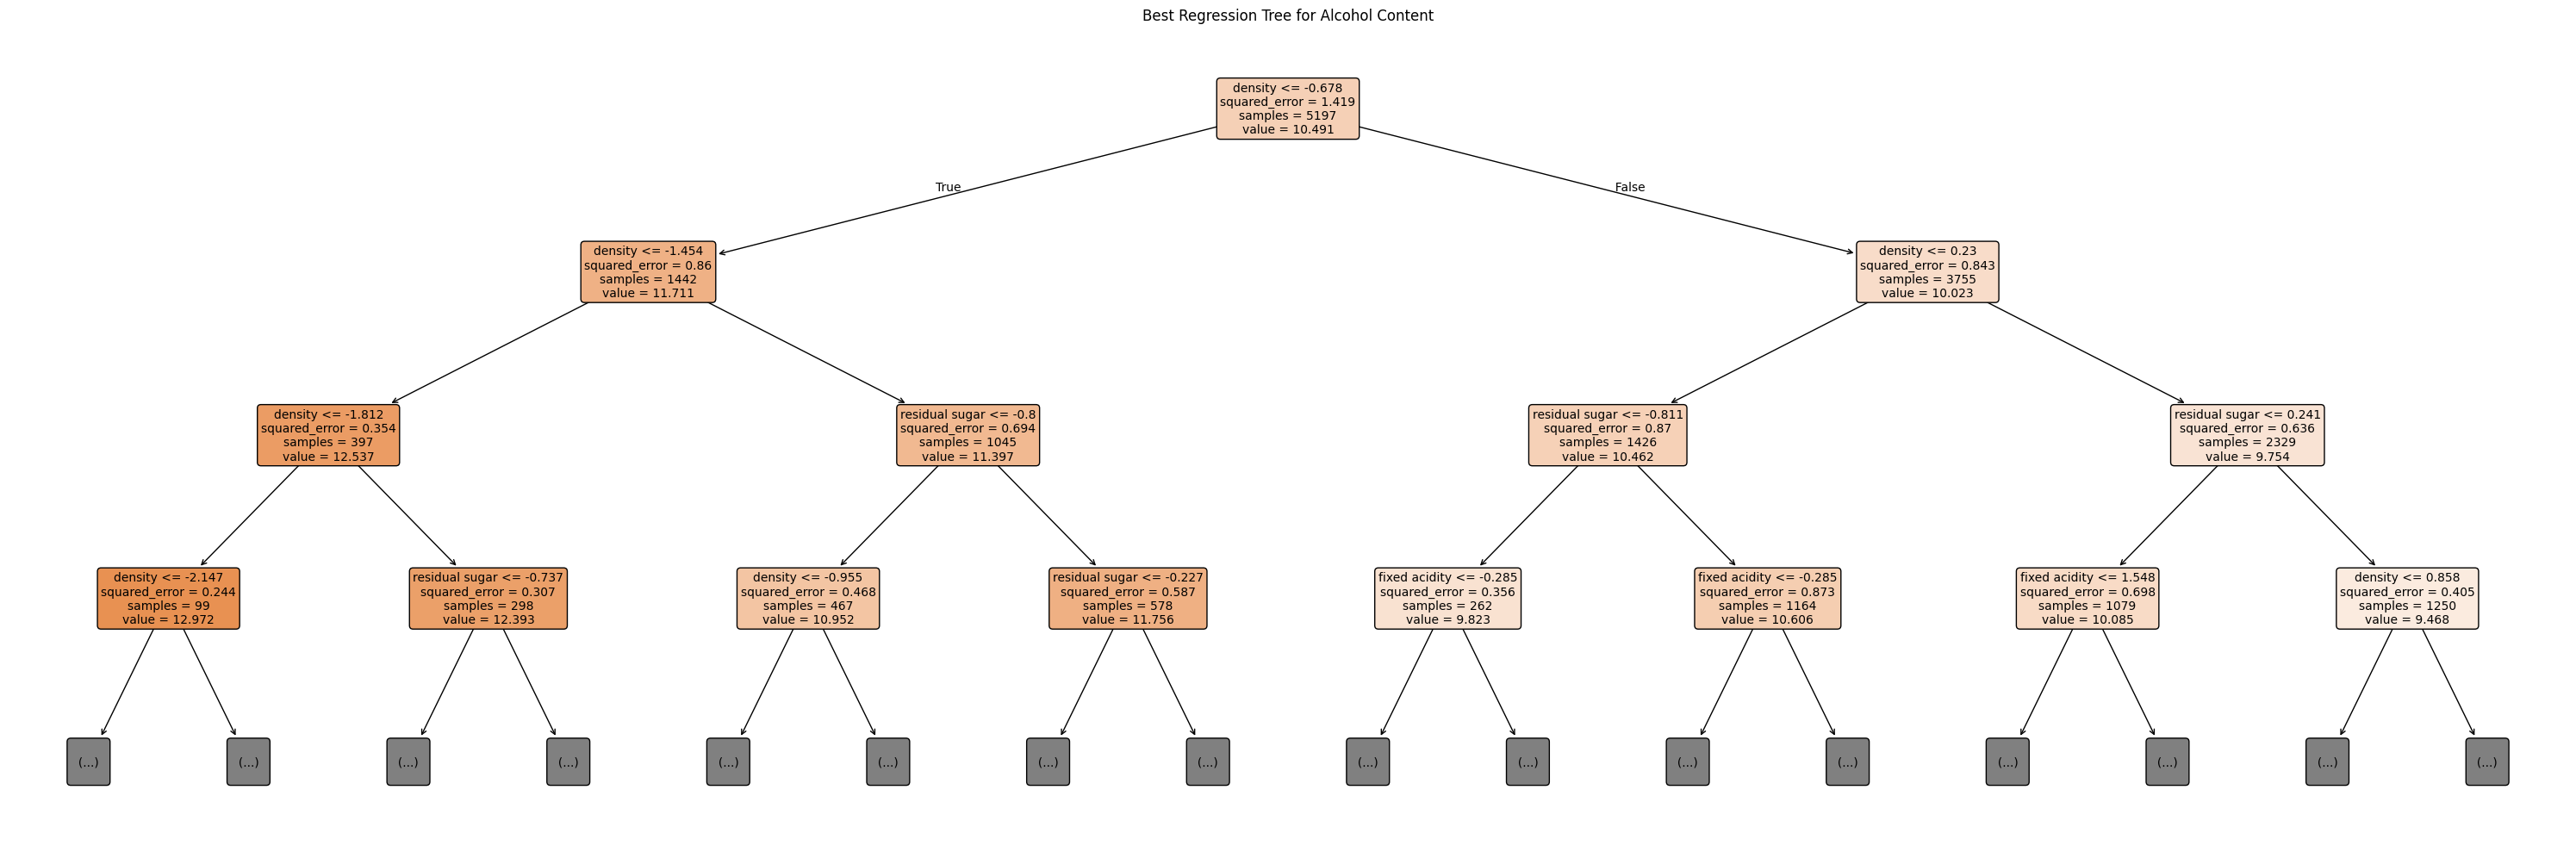

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 10))
plot_tree(
    best_tree,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth = 3
)
plt.title("Best Regression Tree for Alcohol Content")
plt.tight_layout()
plt.show()

Since we selected tuning parameters of 9 depth and 5 samples per leaf, this tree gets complex and confusing quickly! To allow for better readability, the plot is only displaying the first 3 layers of the regression tree. Its important to note that the first decision is made off of density being <= -0.678 or not.

## Random Forest model

In [53]:
from sklearn.ensemble import RandomForestRegressor

parameter = {
    'max_features': range(1,5),        # max features to consider at each split
    'max_depth': [3, 5, 8, 10, 15],
    'min_samples_leaf': [1, 5, 10, 20, 50]       # minimum samples per leaf
}

rf_cv = GridSearchCV(
    RandomForestRegressor(n_estimators=100, random_state=7),
    parameter,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1    # uses all available CPU cores to speed up the search
)
rf_cv.fit(X_train_tree, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=7), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 8, 10, 15],
                         'max_features': range(1, 5),
                         'min_samples_leaf': [1, 5, 10, 20, 50]},
             scoring='neg_mean_squared_error')

In [54]:
# Find best tuning params
best_rf = rf_cv.best_estimator_

print(best_rf)

RandomForestRegressor(max_depth=15, max_features=4, random_state=7)


Grid search found the best parameters for this random forest to be a max depth of 15, with only 4 features being used.

### Random forest plot

To visualize this again, lets plot an individual tree from the forest model

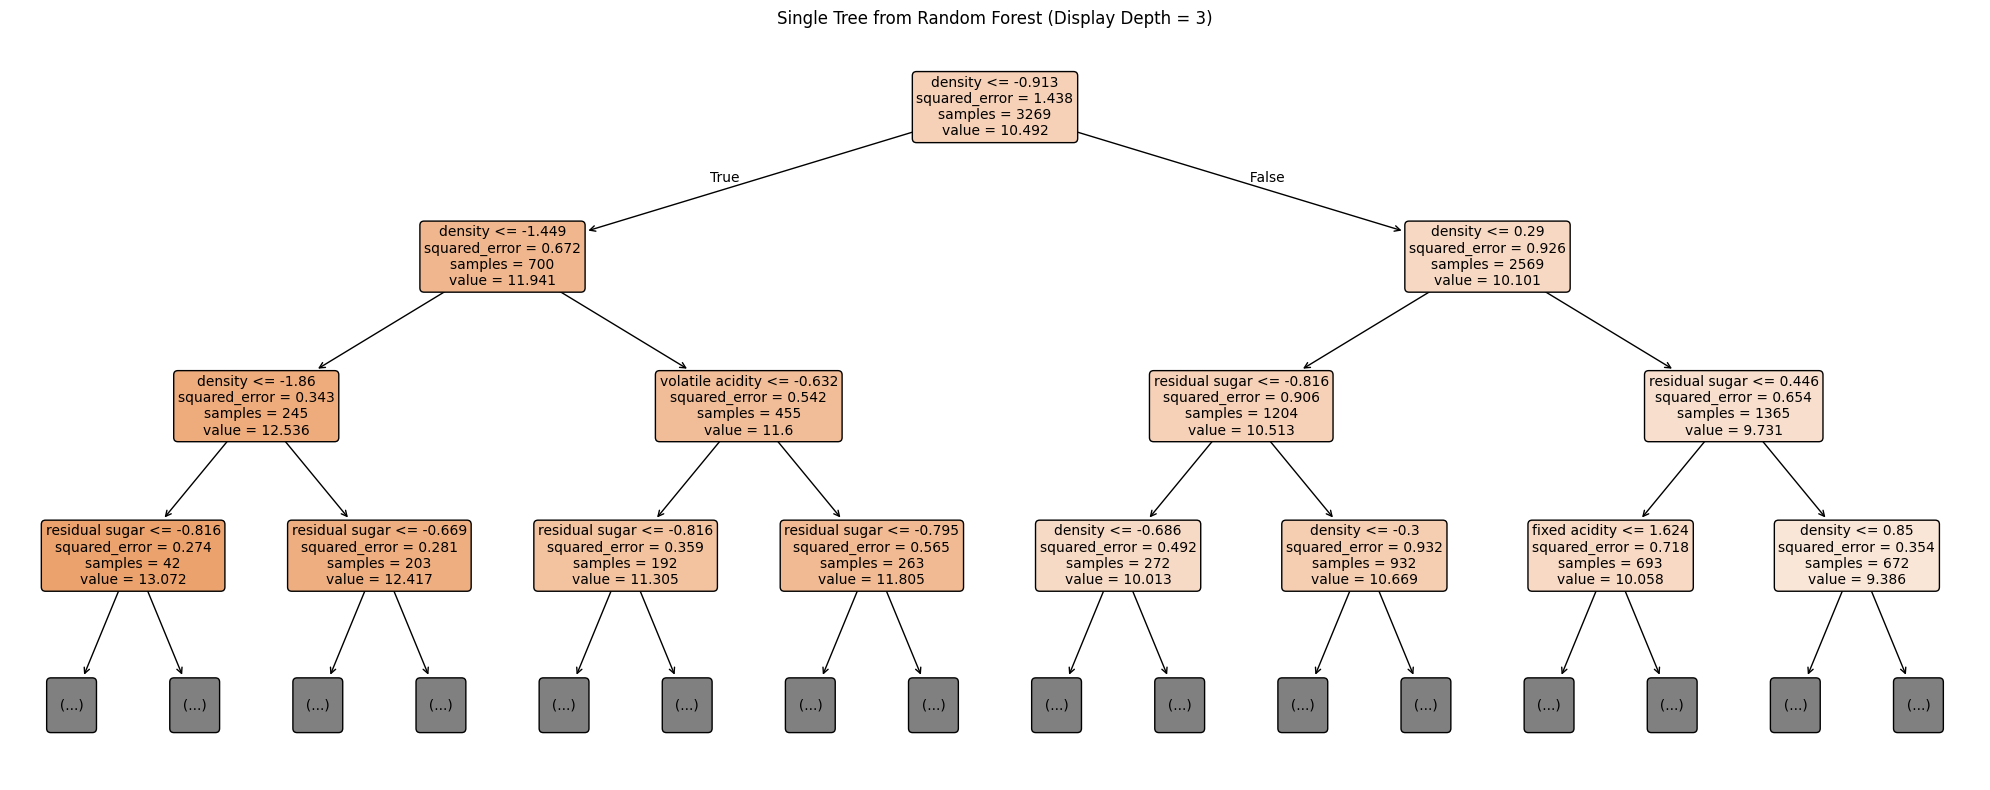

In [55]:
plt.figure(figsize=(20, 8))
plot_tree(best_rf.estimators_[0], feature_names=features,
          filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title("Single Tree from Random Forest (Display Depth = 3)")
plt.tight_layout()
plt.show()

## Testing regression models

Now, lets test our newly created regression tree and random forest model using RMSE and MAE, compared to the previous regression models from homework 7 for predicting alcohol.

In [56]:
# Four best models
X_test_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False).fit_transform(X_test)
X_test_sub = X_test[["fixed acidity", "volatile acidity", "residual sugar", "density", "type", "pH"]]
X_test_tree = X_test[["fixed acidity", "volatile acidity", "residual sugar", "density", "pH"]]

# Generate predictions from each model
mlr_pred = mlr_best.predict(X_test_interact)
lasso_pred = lasso_mod.predict(X_test_sub)
ridge_pred = ridge_mod.predict(X_test_sub)
enet_pred  = en.predict(X_test_sub)
tree_pred = best_tree.predict(X_test_tree)
rf_pred = best_rf.predict(X_test_tree)

models = {
    "MLR (Interactions)": mlr_pred,
    "LASSO": lasso_pred,
    "Ridge": ridge_pred,
    "Elastic Net": enet_pred,
    "Regression Tree": tree_pred,
    "Random Forest": rf_pred
}

# Compare RMSE and MAE for all models
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8}")
print("-" * 43)
for name, preds in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    print(f"{name:<25} {rmse:>8.5f} {mae:>8.5f}")

Model                         RMSE      MAE
-------------------------------------------
MLR (Interactions)         0.40732  0.31201
LASSO                      0.47878  0.36296
Ridge                      0.47881  0.36299
Elastic Net                0.47904  0.36328
Regression Tree            0.54925  0.39586
Random Forest              0.40481  0.27964


When comparing to the methods from homework 7, Random Forest becomes our new best model while using only five predictors! It has the lowest RMSE and MAE compared to every other model. Contrastly, The regression tree model performs significantly worse than every other method, with the highest RMSE and MAE, although the model could be improved if we allow for larger maximum depth in our model fitting.

This may be because a single regression tree is high variance and only used 5 predictors. A single tree makes hard, greedy splits. At each node it picks the single best split and commits to it fully. This means it's very sensitive to the specific training data it saw. However, the random forests fixes these problems through bagging (bootstrap aggregation) and random feature selection, averaging the individual regression trees cancels out individual error and creates a strong model.

## Classification trees and forest using `type` response

### Classification tree

In [16]:
from sklearn.tree import DecisionTreeClassifier

features_clf_tree = ["fixed acidity", "volatile acidity", "residual sugar", "density", "alcohol", "pH"]

X_train_clf_tree = X_train_class[features_clf_tree]
X_test_clf_tree  = X_test_class[features_clf_tree]

# Define parameter grid
parameters = {
    'max_depth': range(2,15),
    'min_samples_leaf': [5, 10, 20, 50, 100]
}

# Grid search with 5-fold CV, using log_loss as scoring metric to match HW7
clf_tree_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=7),
    parameters,
    cv=5,
    scoring='neg_log_loss'
)
clf_tree_cv.fit(X_train_clf_tree, y_train_class)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=7),
             param_grid={'max_depth': range(2, 15),
                         'min_samples_leaf': [5, 10, 20, 50, 100]},
             scoring='neg_log_loss')

In [17]:
# Find best tuning params
best_clf_tree = clf_tree_cv.best_estimator_

print(best_clf_tree)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=7)


This classification tree selected the best tuning parameters to be a max depth of 5 and a minimum samples per leaf of 20, which are both different from the regression tree.

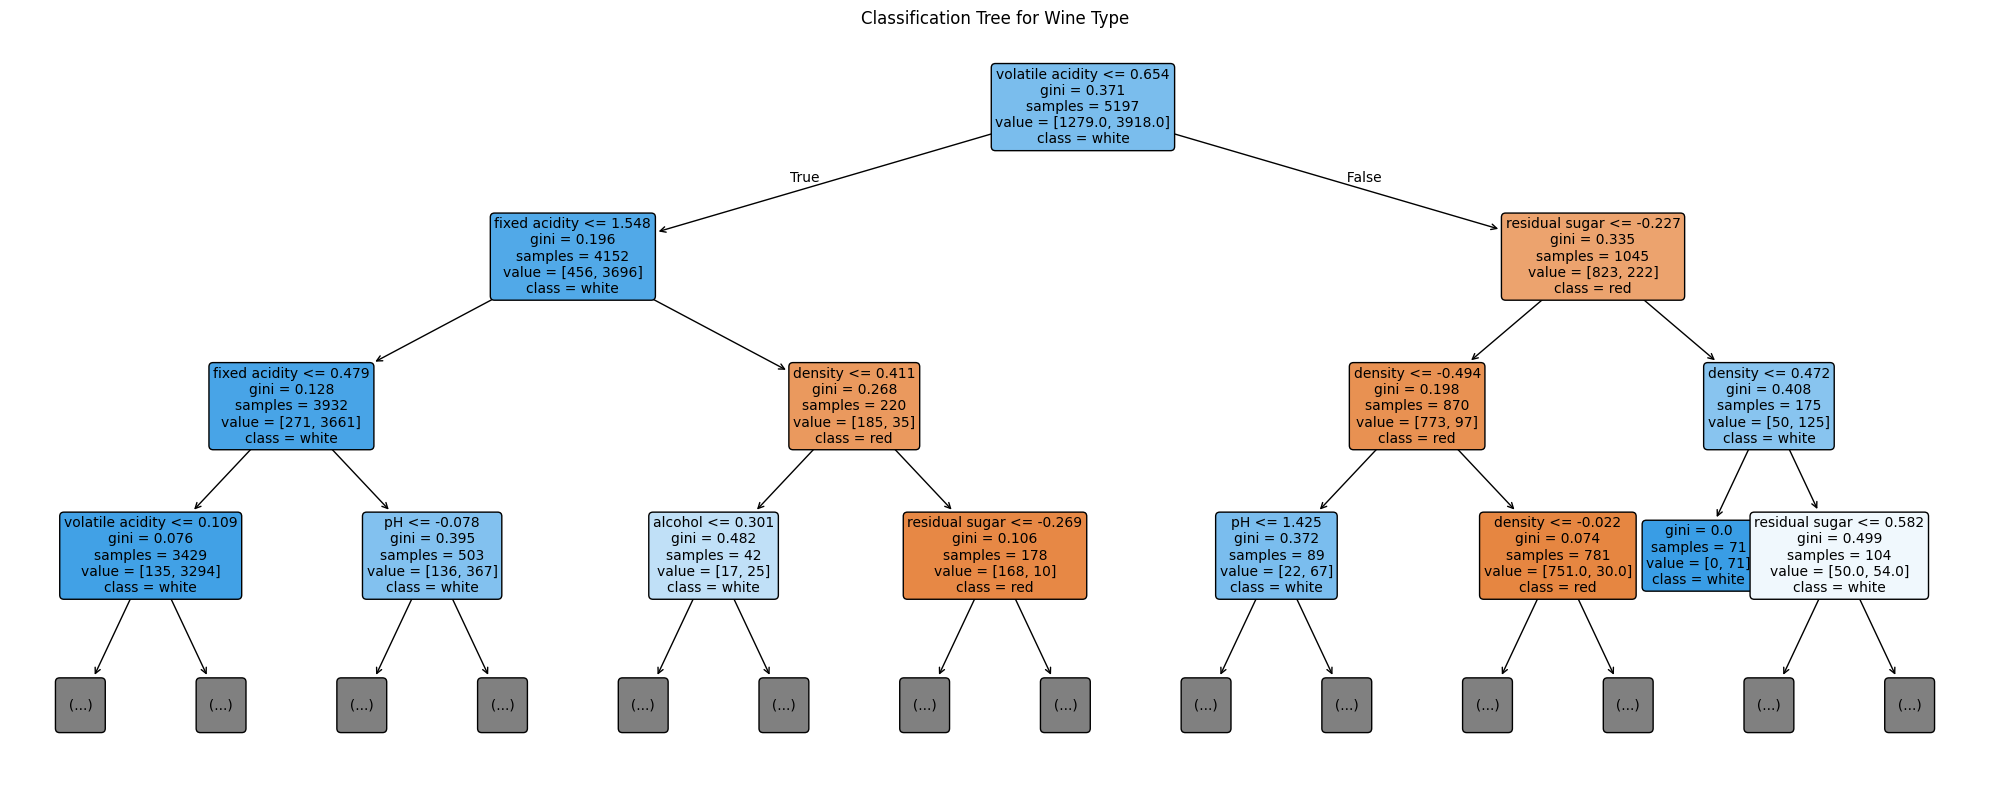

In [22]:
# Classification tree plot

plt.figure(figsize=(20, 8))
plot_tree(
    best_clf_tree,
    feature_names=features_clf_tree,
    class_names=["red", "white"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title("Classification Tree for Wine Type")
plt.tight_layout()
plt.show()

### Random forest classification

In [25]:
from sklearn.ensemble import RandomForestClassifier

features_clf_tree = ["fixed acidity", "volatile acidity", "residual sugar", "density", "alcohol", "pH"]

X_train_clf_tree = X_train_class[features_clf_tree]
X_test_clf_tree  = X_test_class[features_clf_tree]

# Define parameter grid
parameters = {
    'max_depth': range(2,15),
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'max_features': range(1,6)
}

# Grid search with 5-fold CV, using log_loss as scoring metric to match HW7
clf_rv_cv = GridSearchCV(
    RandomForestClassifier(n_estimators=75, random_state=7),
    parameters,
    cv=5,
    scoring='neg_log_loss',
    n_jobs = -1
)
clf_rv_cv.fit(X_train_clf_tree, y_train_class)



GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_estimators=75, random_state=7),
             n_jobs=-1,
             param_grid={'max_depth': range(2, 15), 'max_features': range(1, 6),
                         'min_samples_leaf': [5, 10, 20, 50, 100]},
             scoring='neg_log_loss')

In [27]:
# Find best tuning params
best_clf_rf = clf_rv_cv.best_estimator_

print(best_clf_rf)

RandomForestClassifier(max_depth=9, max_features=3, min_samples_leaf=5,
                       n_estimators=75, random_state=7)


This model chooses tuning parameters of a max_depth of 9, max_features of only 3, which is interesting as there are 6 to choose from, and minimum samples per leaf of 5.

## Testing classification models

In [34]:
# Prepare test sets matching exactly what each model was trained on
X_test_interact = PolynomialFeatures(degree=2, interaction_only=True,
                                      include_bias=False).fit_transform(X_test_class)
X_test_csub = X_test_class[["fixed acidity", "volatile acidity", "residual sugar", "density", "alcohol", "pH"]]

# Map models to their corresponding test sets
test_sets = {
    "Logistic Interactions": (log_mod2,    X_test_interact),
    "Logistic LASSO":        (log_lasso,   X_test_csub),
    "Logistic Ridge":        (log_ridge,   X_test_csub),
    "Logistic Elastic Net":  (log_elastic, X_test_csub),
    "Classification Tree":   (best_clf_tree, X_test_csub),
    "Classification Random Forest": (best_clf_rf, X_test_csub)
}

# Compare log-loss and accuracy
print(f"{'Model':<25} {'Log-Loss':>10} {'Accuracy':>10}")
print("-" * 47)
for name, (mod, X_test_i) in test_sets.items():
    preds_prob  = mod.predict_proba(X_test_i)
    preds_class = mod.predict(X_test_i)
    ll  = log_loss(y_test_class, preds_prob)
    acc = accuracy_score(y_test_class, preds_class)
    print(f"{name:<25} {ll:>10.7f} {acc:>10.7f}")

Model                       Log-Loss   Accuracy
-----------------------------------------------
Logistic Interactions      0.0181002  0.9946154
Logistic LASSO             0.0412297  0.9869231
Logistic Ridge             0.0412477  0.9869231
Logistic Elastic Net       0.0412464  0.9869231
Classification Tree        0.2594232  0.9469231
Classification Random Forest  0.0644375  0.9776923


Now we can see how our two new classification models stack up against the previous logistic models! Aside from the interaction model, the other 5 models use the same predictors, so we can get a good idea of how they stack up against each other working with the same variables.

The classification tree performs poorly, having the highest log-loss of 0.259 and lowest accuracy of 94.6%. This is somewhat expected, as explained above with the drawbacks from a single classification tree. The random forest model improves upon the classification tree, with a log-loss of 0.064 and an accuracy of 97.7%. While these are good model metrics, the random forest classification model still doesn't surpass the previous logistic models.